### Purpose
Creating a ML project that uses yolo, bytetrack, and rnns to create a hurricane detection & prediction algorithm that could detect hurricanes based on infrared footage and accurately predict their future pathing

###How the Algorithm Will Work
YOLO (you only look once) model will initially detect when a hurricane forms
ByteTrack algorithm will output the number of hurricanes it detects, their size, and their relative velocities
A many to many RNN will take that data and use it predict the pathing of the hurricane and potentially when the hurricane disappears

###Creating the Dataset
All footage of hurricanes (that are infrared, ~15 minutes, long year-round) will be recorded from weather.gov’s redirect links. To get the data, I will be using the yt-dlp command to download the redirect links in a mp4 format. In addition, NodeJS 22 will be the javascript runtime environment to resolve the issues   

After that, I would upload the footage to roboflow and manually splice the footage and draw the bounding boxes. (I'm fully aware that there is an AI assistent that could help me, but unfortunately, it didn't perform well in my case).

###Videos Used In the Training Set
* 2024 — https://youtu.be/w2MM7BIpqYY
* 2023 — https://youtu.be/ANb9AQYFA94
* 2022 — https://youtu.be/hTmjRqykmdM
* 2021 — https://youtu.be/2yb0Ra5AZHs
* 2020 — https://youtu.be/Lthy2r_91_Q
* 2019 — https://youtu.be/XHHQEByoeCo

###Kaggle Link to Dataset
* https://www.kaggle.com/datasets/bot5563/labelled-infrared-hurricane-2019-2024

Keep in mind that it's going to be in COCO format.

###Dataset and Image Detection Module

In total, my dataset contains 553 images with a 70/20/10 split on the training, validation, and test set. Thanks to Roboflow's automatic training features, this module has very solid performance:
* mAP@50 -- 93.1%
* Precision -- 85.2%
* Recall -- 88.2%
* F1 -- 86.7%

After that, I created a simple workflow with Yolo26 for image detection and ByteTrack Tracker for object ids & tracking images across frames, an essential feature for the prediction part of this project.


The roboflow workflow looks like this:
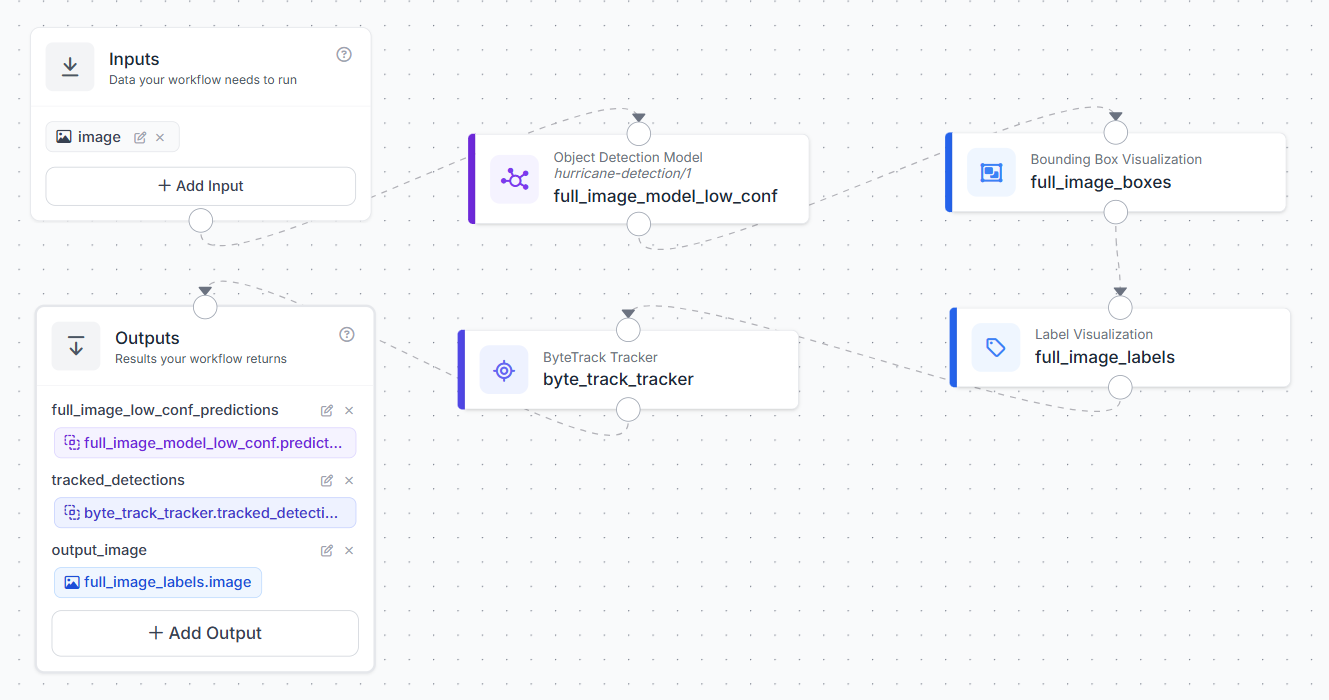

###Class for downloading videos from YT

In [ ]:
#class for downloading video dependencies
class video_downloader():

  def __init__(self, urls):
    self.urls = urls

  #downloads external dependencies
  def install_dependencies():
    !pip install yt-dlp

    !apt-get update
    !curl -fsSL https://deb.nodesource.com/setup_22.x | sudo -E bash -
    !sudo apt install -y nodejs

  #checks dependencies
  #make sure to have node 22+ (because that is what yt-dlp is compatible with)
  def check_dependencies():
    !yt-dlp --version
    !node -v

  #automates the downloading of videos using the stored links
  def download_videos(self, urls=None):
    if urls == None:
      urls = self.urls

    for url in urls:

      #first argument of the command is what url it is downloading
      #second argument is the used javascript runtime
      #third argument is the final merged format
      #fourth argument is to use the external javascript challenge solver script
      !yt-dlp "{url}" --js-runtimes node --merge-output-format mp4 --remote-components ejs:github

###Procedure For Downloading the YT Videos

In [ ]:
urls = ["https://youtu.be/w2MM7BIpqYY",
        "https://youtu.be/ANb9AQYFA94",
        "https://youtu.be/hTmjRqykmdM",
        "https://youtu.be/2yb0Ra5AZHs",
        "https://youtu.be/Lthy2r_91_Q",
        "https://youtu.be/XHHQEByoeCo"]

#installs and checks video downloading section of the project
downloader = video_downloader(urls)

downloader.install_dependencies()
downloader.check_dependencies()

In [ ]:
#downloading the videos
downloader.download_videos()

###Processor For Video Footage

Unfortunately, downloading weights from Roboflow would cost me a mind-boggling $99/month. Thus, I did the next best thing of deploying the model as an API. How the following code will work is that it will take a video file, split it into images, send the images to the roboflow workflow, and return data such as bounding boxes and object ids.

In [ ]:
#downloaing dependnecies
#downloading them could take a while because there are a lot of dependencies to update
#after downloading the dependencies, you may need to restart the session
!pip install inference supervision

In [ ]:
import numpy as np
import pandas as pd
import json
import supervision as sv
from inference import InferencePipeline

test = {}

#class for tracking images across frames
class ImageTracker:

    def __init__(self, info):
        self.WORKSPACE_NAME = info["WORKSPACE_NAME"]
        self.WORKFLOW_ID = info["WORKFLOW_ID"]
        self.ROBOFLOW_API_KEY = info["ROBOFLOW_API_KEY"]
        self.samples_list = [] # Temporary storage for samples
        self.df = pd.DataFrame() # Final DataFrame will be built from samples_list
        self.frame_count_for_debug = 0 # Counter to limit debug prints

    def process_prediction(self, predictions, video_frame):
        """
        Callback function for the Inference Pipeline.
        Note the inclusion of 'self' so we can access instance state safely.
        """
        global test

        test = predictions

        # Correctly access the supervision.Detections object
        tracked_detections_sv = predictions.get("tracked_detections")

        # Check if it's a valid Detections object and if it contains any detections
        if not tracked_detections_sv or len(tracked_detections_sv.xyxy) == 0:
            return

        # Iterate over each detection in the Detections object
        for i in range(len(tracked_detections_sv.xyxy)):
            sample = {}
            xyxy = tracked_detections_sv.xyxy[i]
            x1, y1, x2, y2 = xyxy # xmin, ymin, xmax, ymax

            sample["hurricane_id"] = tracked_detections_sv.tracker_id[i] if tracked_detections_sv.tracker_id is not None and len(tracked_detections_sv.tracker_id) > i else -1
            sample["x"] = (x1 + x2) / 2  # Center x
            sample["y"] = (y1 + y2) / 2 # Center y
            sample["width"] = (x2 - x1)
            sample["height"] = (y2 - y1)
            sample["confidence"] = tracked_detections_sv.confidence[i]
            sample["frame_number"] = video_frame.frame_id
            sample["alive"] = 1

            self.samples_list.append(sample)

    def startPipeline(self, video_path, max_fps=2):
        """Initializes and runs the pipeline, returning the final structured array."""

        self.samples_list = [] # Reset samples for a new pipeline run
        self.frame_count_for_debug = 0 # Reset debug counter for a new pipeline run

        pipeline = InferencePipeline.init_with_workflow(
            api_key=self.ROBOFLOW_API_KEY,
            workspace_name=self.WORKSPACE_NAME,
            workflow_id=self.WORKFLOW_ID,
            video_reference=video_path,
            image_input_name="image",
            max_fps=max_fps,
            on_prediction=self.process_prediction, # Python handles binding 'self' automatically here
        )

        pipeline.start()
        pipeline.join() # Wait until video completes processing

        # Convert the collected samples into a DataFrame
        cols = ["hurricane_id",
                "x",
                "y",
                "width",
                "height",
                "frame_number",
                "confidence",
                "alive"]
        detection_results = pd.DataFrame(self.samples_list, columns=cols)

        return detection_results

###Random Data Values

These values are for testing & debugging the training and prediction workflows only.

In [ ]:
import pandas as pd
import numpy as np

rng = np.random.default_rng()

test_data = rng.integers(0, 10, size=(100, 7))
# Ensure 'alive' column is binary (0 or 1) for BCELoss target
test_data[:, 6] = rng.integers(0, 2, size=(100,))
df = pd.DataFrame(data=test_data, columns=['hurricane_id', 'frame_number', 'x','y','width','height','alive'])

print(df)

    hurricane_id  frame_number  x  y  width  height  alive
0              3             8  8  7      0       2      0
1              3             8  8  3      9       5      1
2              5             1  8  9      4       0      1
3              8             1  9  1      8       8      0
4              7             4  9  6      5       8      0
..           ...           ... .. ..    ...     ...    ...
95             8             8  7  7      7       2      0
96             1             2  2  5      5       3      1
97             0             6  7  4      1       2      0
98             6             4  3  7      1       2      1
99             7             8  9  6      2       5      0

[100 rows x 7 columns]


###Image Processing Procedure

Basically, this cell converts any video into frames that will be fed into the roboflow workflow. That workflow would return the bounding box data that will be converted into a dataframe for efficient operations.

To use this cell, simply upload the hurricane footage into the google colab environment, copy the path to the footage, and pasting it into the video_path variable.

In [ ]:
# Import the userdata module from google.colab
from google.colab import userdata

info = {
    "WORKSPACE_NAME" : "hellos-workspace-burae",
    "WORKFLOW_ID" : "small-object-detection-sahi",
    "ROBOFLOW_API_KEY" : userdata.get('ROBOFLOW_API_KEY')
}

image_processor = ImageTracker(info)

video_path = '/content/Screen Recording 2026-06-19 151841.mp4'

df = image_processor.startPipeline(video_path, max_fps=2)

In [ ]:
print(df)

     hurricane_id      x      y  width  height  frame_number  confidence  \
0              57  580.5  348.0  129.0   112.0             4    0.781166   
1              57  581.5  346.0  131.0   110.0             5    0.770549   
2              57  581.5  346.0  131.0   110.0             6    0.770484   
3              57  579.0  339.5  122.0    99.0             7    0.662093   
4              57  578.5  337.0  125.0    98.0             8    0.726334   
..            ...    ...    ...    ...     ...           ...         ...   
465            57  397.5  290.5  121.0   107.0           476    0.888947   
466            57  397.5  290.0  121.0   106.0           477    0.889312   
467            57  397.5  290.0  121.0   106.0           478    0.890697   
468            57  397.5  290.0  121.0   106.0           479    0.890698   
469            57  397.5  290.0  121.0   106.0           480    0.892014   

     alive  
0        1  
1        1  
2        1  
3        1  
4        1  
..     ..

###Downloading DataFrame as CSV
The below cell is for downloading the dataframe as a csv so that I won't need to constantly re-run the yolo workflow to tune my RNN.

The cell below that is for uploading the csv as a dataframe.

In [ ]:
df.to_csv('hurricane_data.csv', index=False)

In [23]:
import pandas as pd
import numpy as np

df = pd.read_csv('hurricane_data.csv')

### Sliding Window for RNN Data Preparation

To prepare the data for a Recurrent Neural Network (RNN), we need to transform the time-series data into sequences. An RNN processes data sequentially, where each prediction depends on the previous inputs. The sliding window technique is commonly used for this:

1.  **Input Sequence (X)**: We define a `sequence_length` (e.g., 5 frames). For each hurricane, we take a window of `sequence_length` consecutive frames as input.
2.  **Target Sequence (y)**: Corresponding to each input sequence, we define a `prediction_horizon` (e.g., 1 frame). The target for the input sequence will be the `prediction_horizon` number of frames *immediately following* the input sequence.

This function will iterate through each `hurricane_id` in your DataFrame, applying this sliding window to create a dataset suitable for training your RNN. We'll be predicting the next `prediction_horizon` elements based on the `sequence_length` preceding elements.

In addition to the AI generated code, I made two adjustment. One, if there are less than 5 frames for an identified hurricane, the data will be discarded (since it's likely noise). Two, if there are less data in the prediction than the prediction horizon, I the prediction tensor with zeros (perfectly acceptable in my use case).

In [3]:
def create_sequences(df, sequence_length, prediction_horizon, features, target_features, pad_end=False):
    X, y = [], []
    for hurricane_id in df['hurricane_id'].unique():
        hurricane_df = df[df['hurricane_id'] == hurricane_id].sort_values(by='frame_number')

        # Adjustment 1: Discard hurricane data if it's too short for even one sequence
        if len(hurricane_df) < sequence_length:
          continue

        data = hurricane_df[features].values
        targets = hurricane_df[target_features].values

        index_size = len(hurricane_df) - sequence_length

        # This logic ensures that if pad_end is False, the loop stops early enough
        # that no target sequence will require padding. If pad_end is True,
        # index_size is not reduced, allowing the loop to run further and trigger padding.
        if not pad_end:
          index_size -= (prediction_horizon + 1)

          # Ensure index_size is not negative (no sequences can be formed)
          if index_size < 0:
              index_size = 0

        for i in range(index_size):
            X.append(data[i:(i + sequence_length)])

            # Adjustment 2: Zero-padding for target sequences shorter than prediction_horizon
            # This else block is reached when the target sequence would extend beyond the dataframe.
            if ((i + sequence_length + prediction_horizon) < len(hurricane_df)):
                y.append(targets[(i + sequence_length):(i + sequence_length + prediction_horizon)])
            else:
                sample = targets[(i + sequence_length):]

                if len(sample) < prediction_horizon:
                    # Pad with zeros to meet prediction_horizon length
                    padding_needed = prediction_horizon - len(sample)
                    padding = np.zeros((padding_needed, len(target_features)))
                    # Corrected np.vstack syntax
                    sample = np.vstack((sample, padding))

                y.append(sample)

    # Ensure we return PyTorch tensors
    if len(X) == 0:
        return torch.tensor([]), torch.tensor([])

    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(np.array(y), dtype=torch.float32)

### DataLoader Class

In [4]:
import torch
from torch.utils.data import Dataset

# different from CNN which uses ImageFolder method, we don't have such method for RNN, so we need to write the dataset class ourselves, reference tutorial is in the main documentation
class HurricaneDataset(Dataset):
    def __init__(self, train_x, train_y):
        super(Dataset, self).__init__()
        # Expecting train_x and train_y to already be torch.Tensors
        self.x = train_x
        self.y = train_y

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

###Data Processing Procedure

These cells will be responsible for splitting and loading data into DataLoaders to efficiently train the class.

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

sequence_length = 5
prediction_horizon = 3 # Number of future frames to predict

# Define the features to be used for input (X) and target (y)
# For simplicity, let's use x, y, width, height as features
# and predict the next x, y, width, height
features = ['x', 'y', 'width', 'height', 'alive']

# Create sequences from the processed DataFrame
X, y = create_sequences(df, sequence_length, prediction_horizon, features, features, pad_end=True)

print(f"Shape of X (input sequences): {X.shape}")
print(f"Shape of y (target sequences): {y.shape}")

Shape of X (input sequences): torch.Size([465, 5, 5])
Shape of y (target sequences): torch.Size([465, 3, 5])


In [25]:
print(y)

tensor([[[578.5000, 337.5000, 123.0000,  99.0000,   1.0000],
         [578.5000, 338.5000, 127.0000, 105.0000,   1.0000],
         [578.0000, 341.5000, 128.0000, 111.0000,   1.0000]],

        [[578.5000, 338.5000, 127.0000, 105.0000,   1.0000],
         [578.0000, 341.5000, 128.0000, 111.0000,   1.0000],
         [577.0000, 341.5000, 128.0000, 111.0000,   1.0000]],

        [[578.0000, 341.5000, 128.0000, 111.0000,   1.0000],
         [577.0000, 341.5000, 128.0000, 111.0000,   1.0000],
         [575.5000, 339.5000, 131.0000, 111.0000,   1.0000]],

        ...,

        [[397.5000, 290.0000, 121.0000, 106.0000,   1.0000],
         [397.5000, 290.0000, 121.0000, 106.0000,   1.0000],
         [397.5000, 290.0000, 121.0000, 106.0000,   1.0000]],

        [[397.5000, 290.0000, 121.0000, 106.0000,   1.0000],
         [397.5000, 290.0000, 121.0000, 106.0000,   1.0000],
         [  0.0000,   0.0000,   0.0000,   0.0000,   0.0000]],

        [[397.5000, 290.0000, 121.0000, 106.0000,   1.0000],


In [26]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

train_x, test_x, train_y, test_y = train_test_split(X, y, test_size=0.2, random_state=42)

train_dataset = HurricaneDataset(train_x, train_y)
test_dataset = HurricaneDataset(test_x, test_y)

# now prepare the dataloader for training set and evaluation set, and hyperparameters
batch_size = 5

train_loader = DataLoader(train_dataset,
                          batch_size=batch_size,
                          shuffle=True,
                          num_workers=2)

test_loader = DataLoader(test_dataset,
                         batch_size = batch_size,
                         shuffle=False,
                         num_workers=2)


###RNN

As you can tell below, this isn't an ordinary RNN. For this portion of the project, I'd like the RNN to predict both the future path of the hurricane and if the hurricane is dead or alive. (Initially, I planned to simply have the RNN predict [0,0,0,0] to signify a dead hurricane. However, I was advised against this since a change from say 40px to 0px width would probably cause an exploding gradient that messes up my model).

To make things efficient, this RNN will be a multi-task model that outputs a tuple (binary dead/alive, tensor on bounding boxes). There will be two heads: a binary classification one with sigmoid and regression. The former is responsible for predicting whether the hurricane would be alive, and the latter will predict the bounding box dimensions.

In [8]:
import torch.nn as nn

# model design goes here
class RNN(nn.Module):

    # there is no "correct" RNN model architecture for this lab either, you can start with a naive model as follows:
    def __init__(self, input_feature_size, hidden_size, num_layers, prediction_horizon):
        super(RNN, self).__init__()

        self.prediction_horizon = prediction_horizon
        self.lstm = nn.LSTM(input_size=input_feature_size,
                            hidden_size = hidden_size,
                            num_layers=num_layers,
                            batch_first=True)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

        self.linear1 = nn.Linear(in_features=hidden_size, out_features=256)

        #predicts the if the next 'prediction_horizon' steps will be alive or not
        self.linear2 = nn.Linear(in_features=256, out_features=self.prediction_horizon)

        #predicts the bounding box information for 'prediction_horizon' steps
        self.linear3 = nn.Linear(in_features=256, out_features=self.prediction_horizon * 4)


    def forward(self, x):
        out, hidden = self.lstm(x) # Changed from self.lstm(x) to self.gru(x)
        out = out[:, -1, :]
        out = self.linear1(out)
        out = self.relu(out)

        #responsible for outputting dead or alive hurricane (probabilities)
        binary_pred = self.linear2(out)
        binary_pred = self.sigmoid(binary_pred)

        #responsible for predicting bounding boxes, reshaped for multi-step prediction
        bounding_pred = self.linear3(out)
        bounding_pred = bounding_pred.view(-1, self.prediction_horizon, 4)

        return (binary_pred, bounding_pred)

###Masked Multipliers Class

The class serves two purposes: a custom loss function for our rnn and holding two parameters that act as multipliers for the two losses. As standard, MSE loss will be used for the regression portion and BCE loss will be used for the binary classification portion. The tricky part is how to combine these losses to make sense. The algorithm used in this class is described in this paper about multi-task models: https://arxiv.org/pdf/1705.07115.

As stated in the paper, since these results come from different distributions (bernolli and gaussian), it's possible that the results output different ranges. If these ranges are unbalanced for, one distribution is going to contribute a lot more to the loss function and affect backpropagation. To compensate, one could use an approach to weigh and aggregate the loss values: e.g., a * bce-loss + b * mse-loss.

Finding such values a & b manually would be tedious. Also, using a model to find them wouldn't be ideal because said model could easily cheat the system by setting a & b to 0 or a negative value.

Thus, they proposed the following loss function: 1/(2sigma$^2_1$)L$_1$(W) + 1/(sigma$^2_2$)L$_2$(W) + log(sigma$_1$) + log(sigma$_2$).
* L$_1$(W) -- euclidean loss
* L$_2$(W) -- cross entropy loss
* a = log(sigma$^2_1$)
* b = log(sigma$^2_2$)
* sigma$^2$ = exp(a) or exp(b)
* log(sigma) = 0.5a or 0.5b

Thus, for the code, it converts a & b into
* 1/exp(-a) + 0.5*a
* 1/exp(-b) + 0.5*b

Although one could try to optimize for sigma directly instead of something like s = log(sigma$^2_1$), the paper stated that in practice, it is best to optimize for s = log(sigma$^2_1$) because it is more stable.

In this equation, it would be impossible for the model to cheat either sigma values (by setting them to zero or any small number) bc/ either the 1/(sigma$^2$) or log(sigma) parts of the equation would increase the loss dramatically.

Generally speaking, one can construct these custom loss functions through the following steps:
* use the appropriate loss function (MSE for regression, BCE for binary classification, and CE for multi classification)
* allocating a parameter to the loss, and applying
* create the loss equation using the following equation

$TotalLoss = sum_{i=1 to N} (C_i * exp(-s_i) * L_i(W) + 0.5 * s_i)$
* $L_i(W)$ -- output of the loss function
* s_i -- loss multiplier
* C_i -- constant factor (0.5 for classification & 1.0 for classification)

After computing the loss, we could call .backwards() on it like any other loss function output because PyTorch's autograd system would correct the gradients for us.


In [28]:
class MaskedMultiTaskLoss(nn.Module):
    def __init__(self):
        super(MaskedMultiTaskLoss, self).__init__()

        # HERE THEY ARE: Two trainable internal parameters initialized at 0.0
        # PyTorch tracks these exactly like it tracks neural network weights!
        self.log_vars = nn.Parameter(torch.zeros(2))

        self.mse = nn.MSELoss(reduction='none') # Per-element MSE so we can mask it
        self.bce = nn.BCELoss()

    def forward(self, pred_active, pred_bbox, true_active, true_bbox):
        # Step A: Raw Classification Loss
        loss_class = self.bce(pred_active, true_active)

        # Step B: Masked Raw Regression Loss
        raw_mse_loss = self.mse(pred_bbox, true_bbox)

        # Expand true_active to match the dimensions of raw_mse_loss for element-wise multiplication
        # true_active was (batch_size, prediction_horizon), now becomes (batch_size, prediction_horizon, 1)
        # then expanded to (batch_size, prediction_horizon, 4)
        expanded_true_active = true_active.unsqueeze(-1).expand_as(raw_mse_loss)
        masked_mse_loss = raw_mse_loss * expanded_true_active # Erase loss if storm is dead

        loss_reg = masked_mse_loss.mean()

        # Step C: The Multipliers Come Into Play!
        # Convert log_vars to precision multipliers (1 / sigma^2)
        precision1 = torch.exp(-self.log_vars[0]) # Multiplier for Regression
        precision2 = torch.exp(-self.log_vars[1]) # Multiplier for Classification

        # We multiply the individual losses by our dynamic multipliers
        # and append the log penalty terms to prevent cheating.
        total_loss = (0.5 * precision1 * loss_reg) + \
                     (precision2 * loss_class) + \
                     (0.5 * self.log_vars[0]) + \
                     (0.5 * self.log_vars[1])

        return total_loss

###Model Training Procedure

Our MaskedMultiTaskLoss is our loss function. As for the optimizer, the standard Adam should be good enough. An importants step is to pass in parameters from both our loss and rnn model to ensure all parameters are properly optimized. The rest of the code is just a standard training loop.

In [29]:
from torch.optim import Adam

hidden_size = 256
num_layers = 2
learning_rate = 0.001

# instantiate your rnn model and move to device as in cnn section
rnn = RNN(5, hidden_size, num_layers, prediction_horizon).to(device) # Pass prediction_horizon
criterion = MaskedMultiTaskLoss()

# you can start with using Adam as optimizer as well
all_trainable_parameters = list(rnn.parameters()) + list(criterion.parameters())
optimizer = torch.optim.Adam(all_trainable_parameters, lr=learning_rate)

In [33]:
epoch_size = 70

# start training
rnn.train()
for epoch in range(epoch_size): # start with 50 epochs

    loss = 0.0 # you can print out average loss per batch every certain batches

    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # get inputs and target values from dataloaders and move to device
        inputs = inputs.to(device)
        targets = targets.to(device)

        # forward -> compute loss -> backward propogation -> optimize (see tutorial mentioned in main documentation)
        optimizer.zero_grad()

        # 1. Run the forward pass through the model to get predictions
        pred_active, pred_bbox = rnn(inputs)

        true_active = targets[:,:,4]
        true_bbox = targets[:,:,:4]

        # Removed debug print statements as issue is addressed.

        batch_loss = criterion(pred_active, pred_bbox, true_active, true_bbox)
        batch_loss.backward()
        optimizer.step()

        loss += batch_loss# add loss for current batch
        if batch_idx % 100 == 99:    # print average loss per batch every 100 batches
            print(f'[{epoch + 1}, {batch_idx + 1:5d}] loss: {loss / 100:.3f}')
            loss = 0.0

print('Finished Training')

Finished Training


###Model Evaluation Procedure

Since the results should come from data distributions, I've decided to evaluate the results seperately using the standard approaches for both: r2 score for the regression portion and accuracy_score for the binary classification portion.

In [34]:
binary_pred_list = [] # Renamed to avoid conflict with function output
binary_truth_list = []

reg_pred_list = [] # Renamed
reg_truth_list = []

# evaluation
rnn.eval()
with torch.no_grad():
    for (inputs, targets) in test_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)

        # Extract true_active and true_bbox directly from targets
        true_active_batch = targets[:, :, 4] # Shape: (batch_size, prediction_horizon)
        true_bbox_batch = targets[:, :, :4]  # Shape: (batch_size, prediction_horizon, 4)

        # Get model predictions
        pred_active_batch, pred_bbox_batch = rnn(inputs)

        # Move to CPU and convert to numpy for collection
        binary_pred_list.append(pred_active_batch.detach().cpu().numpy().reshape(-1)) # pred_active is already (batch_size, prediction_horizon)
        binary_truth_list.append(true_active_batch.detach().cpu().numpy().reshape(-1))

        reg_pred_list.append(pred_bbox_batch.detach().cpu().numpy().reshape(-1, 4)) # pred_bbox is already (batch_size, prediction_horizon, 4)
        reg_truth_list.append(true_bbox_batch.detach().cpu().numpy().reshape(-1, 4))


In [35]:
from sklearn.metrics import r2_score, accuracy_score

# Concatenate all collected data
binary_pred = np.concatenate(binary_pred_list)
binary_truth = np.concatenate(binary_truth_list)

reg_pred = np.concatenate(reg_pred_list)
reg_truth = np.concatenate(reg_truth_list)

# For accuracy, threshold the probabilities to get binary predictions (0 or 1)
binary_pred_thresholded = (binary_pred > 0.5).astype(int)

# Use r2_score from sklearn for bounding box regression
r2score = r2_score(reg_truth, reg_pred)
print(f"Performance of the bbox portion (R2 Score): {r2score:.4f}")

# Use accuracy_score from sklearn for binary classification
accuracy = accuracy_score(binary_truth, binary_pred_thresholded)
print(f"Performance of the binary portion (Accuracy): {accuracy:.4f}")


Performance of the bbox portion (R2 Score): 0.7124
Performance of the binary portion (Accuracy): 1.0000


In [19]:
indices = np.argsort(reg_pred[:, 0])

print(reg_pred[indices])

[[0.3681566  0.49816507 0.09813724 0.16832021]
 [0.36815703 0.49816555 0.09813723 0.1683204 ]
 [0.36815992 0.498169   0.0981375  0.1683218 ]
 ...
 [0.371605   0.4947404  0.08869357 0.16346894]
 [0.3716065  0.49474272 0.08869371 0.16346945]
 [0.37162614 0.49477407 0.08869557 0.16347632]]


In [20]:
indices = np.argsort(reg_truth[:, 0])

print(reg_truth[indices])

[[0.3134858  0.4991409  0.09542587 0.1838488 ]
 [0.3134858  0.4991409  0.09542587 0.1838488 ]
 [0.3134858  0.4991409  0.09542587 0.1838488 ]
 ...
 [0.45583597 0.58676976 0.10094637 0.19072165]
 [0.45623028 0.5798969  0.09700315 0.17010309]
 [0.45623028 0.58161515 0.10015773 0.18041237]]


###Results and Conclusion
The above results you see are the workflow on a small clip of the 2019 Hurricane footage. I adjusted the model so that the RNN takes 5 sequences and attempts to predict the nxt 3 sequences. After 70 epochs, the R2 score is .71 and classification accuracy is 100%. Though admittedly, when used on the same dataset, if one tries to make the RNN input 10 sequences and attempts to predict the next 8 sequences, the R2 score will dramatically decrease to .48. That result is expected though because trying to predict 8 sequences while having a dataset of 470 is ambitious to say the least.

The reason that I didn't use the whole is due to the massive dataset size and cost of credits.

Just this 17 second footage created 460 tuples of data. If I fed all 6 of the 15 minute videos, I'd end up with a pretty big dataset. Consequently, such a huge upload may rapidly use up all my credits, which is an expense I'd rather avoid. In addition, just this 17 seconds of footage took ~4 minutes to finish processing. Doing the math, this means a 15 minute video would take more than 3 hours to finish processing.

I'm aware an alternative option is to download the yolo wieghts and use ultralytics; however, that would cost me $99. Plus, it took me 14 minutes to train the Roboflow workflow. So, this will be the more time efficient option.

But at least this decent performance show that this concept of using yolo+bytetrack to detect hurricanes in satellite image, and then using rnns to predict hurricane paths should work well in theory.

###Limitations
A major limitation about ML is that it’s very difficult for models to adapt to changing conditions. Thus, as global temperatures continue to rise, it’s possible that the RNN cannot keep up with these changes: leading to inaccurate predictions.

The model was trained on data from weather.gov, and several aspects of the data limit this system’s practicality: infrared only footage, specific angle of the footage, and limited footage. The videos are infrared, meaning that none-infrared data could lead to inaccurate predictions & detections. All of this footage is of one angle over the Atlantic Ocean. Consequently, predictions of hurricanes will only be accurate over this angle over the Atlantic Ocean specifically. I highly doubt that this model could predict storms in the Pacific or Indian Ocean well. Finally, this site only has data between 1978 and 2024. While that should be plenty for this project, a much larger dataset would improve accuracy significantly.

There is also the limitation of time where processing a 15 minute video for its bounding box outputs could take hours. However, if one has a lot of free time to spare, then this could be overcomed.

###Suggestions/Enhancements for Future Iterations of this Project
A possible idea to improve this project would be to input additional information in the RNN input to better predict hurricane paths (e.g., air pressure and sea surface temperature of the hurricane eye).

Perhaps one could also ensure that this RNN works globally by inputting the exact longitude and latitude as well and retraing the RNN, so that the RNN isn't stuck to predicting this one region over the Atlantic Ocean specifically. (Retraining the Yolo shouldn't be necessary bc/ all hurricanes kinda look the same).

If one is ambitious, perhaps instead of just predicting hurricane paths, one could try to predict when and where hurricanes would spawn in the world.

Finally, perhaps experiement RNN architectures. For instance, I've heard of something called a GRU that I shall further look into.
